# **Exercise 1: Map-to-Satellite Translation (Cartography)**

In [1]:
!pip install -q kaggle
!pip install -q torch torchvision matplotlib tqdm

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"srajankushwaha","key":"8a8eec217fb02b689923d019df5cdf4e"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle datasets download -d vikramtiwari/pix2pix-dataset

Dataset URL: https://www.kaggle.com/datasets/vikramtiwari/pix2pix-dataset
License(s): unknown
100% 2.39G/2.40G [00:18<00:00, 232MB/s]
100% 2.40G/2.40G [00:18<00:00, 140MB/s]


In [11]:
!unzip pix2pix-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: edges2shoes/edges2shoes/train/8200_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8201_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8202_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8203_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8204_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8205_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8206_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8207_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8208_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8209_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/820_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8210_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8211_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8212_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8213_AB.jpg  
  inflating: edges2shoes/edges2shoes/train/8214_AB.jpg  
  inflating: edges2shoes/edges2shoes/t

In [12]:
!ls

cityscapes   facades	  maps		       sample_data
edges2shoes  kaggle.json  pix2pix-dataset.zip


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
from tqdm import tqdm

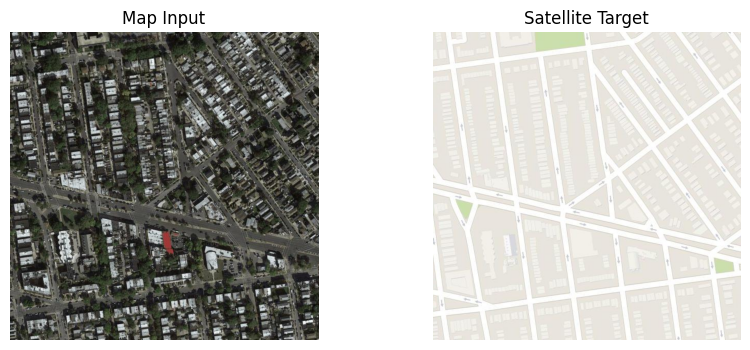

In [30]:
img = Image.open("maps/maps/train/1.jpg")
img = np.array(img)

h,w,_ = img.shape

map_img = img[:,:w//2]
sat_img = img[:,w//2:]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Map Input")
plt.imshow(map_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Satellite Target")
plt.imshow(sat_img)
plt.axis("off")

plt.show()

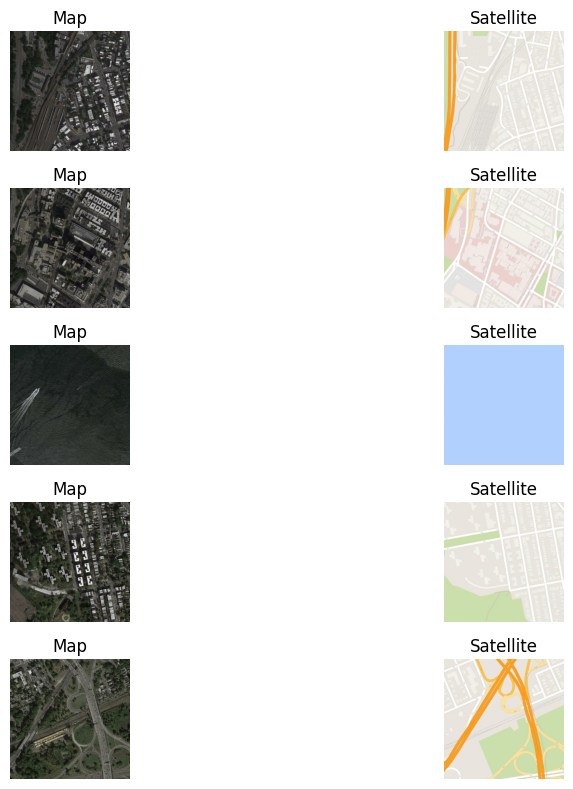

In [31]:
import random

files = os.listdir("maps/maps/train")

plt.figure(figsize=(12,8))

for i in range(5):

    img = Image.open("maps/maps/train/" + random.choice(files))
    img = np.array(img)

    h,w,_ = img.shape

    map_img = img[:,:w//2]
    sat_img = img[:,w//2:]

    plt.subplot(5,2,2*i+1)
    plt.imshow(map_img)
    plt.axis("off")
    plt.title("Map")

    plt.subplot(5,2,2*i+2)
    plt.imshow(sat_img)
    plt.axis("off")
    plt.title("Satellite")

plt.tight_layout()

In [32]:
class MapsDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.root_dir, self.images[idx])
        img = Image.open(img_path).convert("RGB")

        w,h = img.size

        map_img = img.crop((0,0,w//2,h))
        sat_img = img.crop((w//2,0,w,h))

        if self.transform:
            map_img = self.transform(map_img)
            sat_img = self.transform(sat_img)

        return map_img, sat_img

In [34]:
train_dataset = MapsDataset("maps/maps/train", transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

In [35]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [36]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,x,y):
        inp = torch.cat([x,y],dim=1)
        return self.model(inp)

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

In [38]:
bce = nn.BCELoss()
l1 = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [39]:
epochs = 5

G_losses = []
D_losses = []

for epoch in range(epochs):

    loop = tqdm(train_loader)

    for map_img, sat_img in loop:

        map_img = map_img.to(device)
        sat_img = sat_img.to(device)

        fake = G(map_img)

        # Train Discriminator
        D_real = D(map_img, sat_img)
        D_fake = D(map_img, fake.detach())

        loss_real = bce(D_real, torch.ones_like(D_real))
        loss_fake = bce(D_fake, torch.zeros_like(D_fake))

        D_loss = (loss_real + loss_fake)/2

        opt_D.zero_grad()
        D_loss.backward()
        opt_D.step()

        # Train Generator
        D_fake = D(map_img, fake)

        G_loss = bce(D_fake, torch.ones_like(D_fake)) + 100*l1(fake, sat_img)

        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

        loop.set_description(f"Epoch [{epoch}/{epochs}]")

    G_losses.append(G_loss.item())
    D_losses.append(D_loss.item())

Epoch [4/5]: 100%|██████████| 274/274 [00:19<00:00, 14.20it/s]


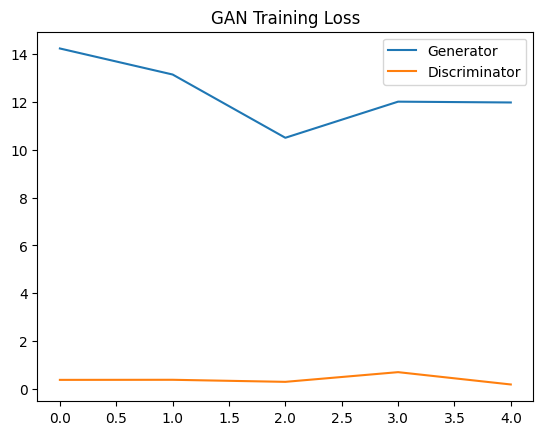

In [43]:
plt.plot(G_losses,label="Generator")
plt.plot(D_losses,label="Discriminator")

plt.title("GAN Training Loss")
plt.legend()
plt.show()

In [44]:
G.eval()

map_img, sat_img = next(iter(train_loader))
map_img = map_img.to(device)

with torch.no_grad():
    fake = G(map_img)

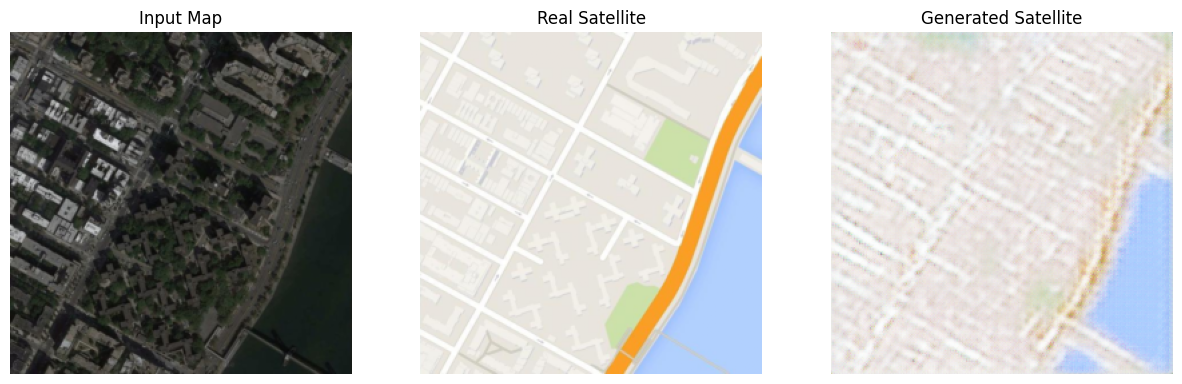

In [46]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Map")
plt.imshow(map_img[0].cpu().permute(1,2,0)*0.5+0.5)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Real Satellite")
plt.imshow(sat_img[0].permute(1,2,0)*0.5+0.5)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Generated Satellite")
plt.imshow(fake[0].cpu().permute(1,2,0)*0.5+0.5)
plt.axis("off")

plt.show()

# **Exercise 2 – Synthetic Medical Image Generation using DCGAN**

In [47]:
!pip install -q kaggle
!pip install -q torch torchvision matplotlib tqdm

In [48]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"srajankushwaha","key":"8a8eec217fb02b689923d019df5cdf4e"}'}

In [49]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [50]:
!kaggle datasets download -d nih-chest-xrays/sample

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/sample
License(s): CC0-1.0
100% 4.20G/4.20G [01:11<00:00, 16.4MB/s]
100% 4.20G/4.20G [01:11<00:00, 62.9MB/s]


In [51]:
!unzip sample.zip

Streaming output truncated to the last 5000 lines.
  inflating: sample/sample/images/00003124_000.png  
  inflating: sample/sample/images/00003129_000.png  
  inflating: sample/sample/images/00003129_001.png  
  inflating: sample/sample/images/00003129_004.png  
  inflating: sample/sample/images/00003129_009.png  
  inflating: sample/sample/images/00003129_011.png  
  inflating: sample/sample/images/00003135_000.png  
  inflating: sample/sample/images/00003140_007.png  
  inflating: sample/sample/images/00003159_001.png  
  inflating: sample/sample/images/00003169_001.png  
  inflating: sample/sample/images/00003177_002.png  
  inflating: sample/sample/images/00003186_004.png  
  inflating: sample/sample/images/00003186_005.png  
  inflating: sample/sample/images/00003190_018.png  
  inflating: sample/sample/images/00003191_001.png  
  inflating: sample/sample/images/00003198_002.png  
  inflating: sample/sample/images/00003198_005.png  
  inflating: sample/sample/images/00003198_009.p

In [52]:
!ls

 cityscapes   'kaggle (1).json'   pix2pix-dataset.zip   sample_labels.csv
 edges2shoes   kaggle.json	  sample	        sample.zip
 facades       maps		  sample_data


In [56]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import random
from tqdm import tqdm

In [55]:
!pip install torch torchvision matplotlib tqdm

In [68]:
!ls sample/images | head

00000013_005.png
00000013_026.png
00000017_001.png
00000030_001.png
00000032_001.png
00000040_003.png
00000042_002.png
00000057_001.png
00000061_002.png
00000061_019.png


In [69]:
path = "sample/images"

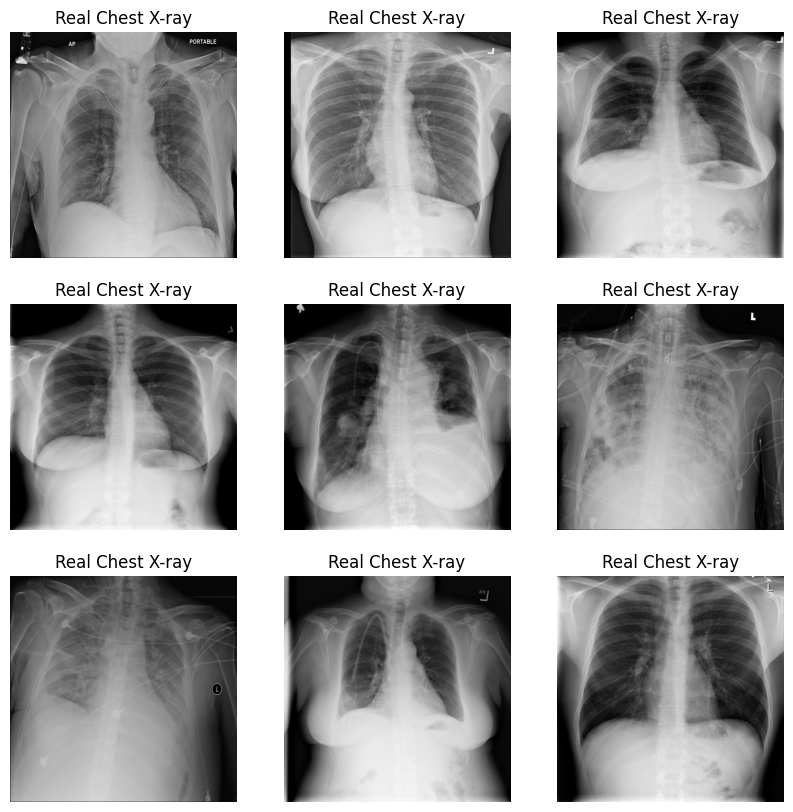

In [72]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

path = "sample/images"   # correct dataset folder

files = os.listdir(path)

plt.figure(figsize=(10,10))

for i in range(9):

    img = Image.open(os.path.join(path, random.choice(files))).convert("L")

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title("Real Chest X-ray")
    plt.axis("off")

plt.show()

In [74]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [75]:
class XrayDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.root_dir, self.images[idx])
        img = Image.open(img_path).convert("L")

        if self.transform:
            img = self.transform(img)

        return img

In [76]:
dataset = XrayDataset(path, transform)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [77]:
dataset = XrayDataset(path, transform)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [78]:
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(100,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.net(x)

In [79]:
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(100,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.net(x)

In [80]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [81]:
import torch.optim as optim

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

In [88]:
from tqdm import tqdm

epochs = 10
z_dim = 100

# Re-instantiate Generator and Discriminator for Exercise 2
G = Generator().to(device)
D = Discriminator().to(device)

G_losses = []
D_losses = []

for epoch in range(epochs):

    loop = tqdm(loader)

    for real in loop:

        real = real.to(device)
        batch_size = real.shape[0]

        noise = torch.randn(batch_size,z_dim,1,1).to(device)
        fake = G(noise)

        # Train Discriminator
        D_real = D(real).view(-1)
        loss_real = criterion(D_real, torch.ones_like(D_real))

        D_fake = D(fake.detach()).view(-1)
        loss_fake = criterion(D_fake, torch.zeros_like(D_fake))

        D_loss = (loss_real + loss_fake)/2

        opt_D.zero_grad()
        D_loss.backward()
        opt_D.step()

        # Train Generator
        output = D(fake).view(-1)
        G_loss = criterion(output, torch.ones_like(output))

        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

        loop.set_description(f"Epoch {epoch}")

    G_losses.append(G_loss.item())
    D_losses.append(D_loss.item())

Epoch 9: 100%|██████████| 88/88 [01:22<00:00,  1.07it/s]


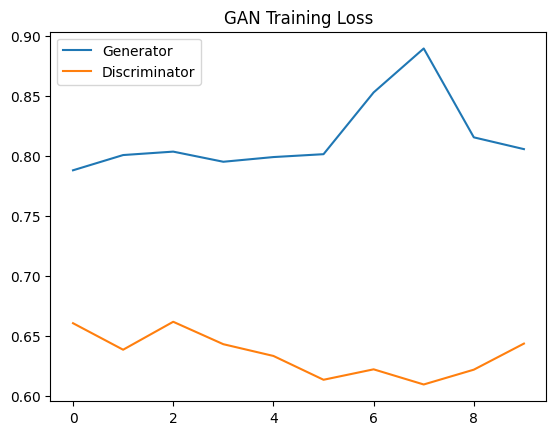

In [89]:
plt.plot(G_losses,label="Generator")
plt.plot(D_losses,label="Discriminator")

plt.title("GAN Training Loss")
plt.legend()
plt.show()

(np.float64(-0.5), np.float64(265.5), np.float64(265.5), np.float64(-0.5))

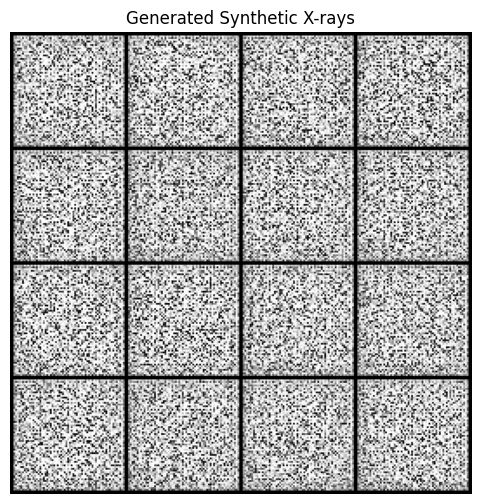

In [90]:
noise = torch.randn(16,100,1,1).to(device)

with torch.no_grad():
    fake = G(noise).cpu()

grid = make_grid(fake, nrow=4, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.title("Generated Synthetic X-rays")
plt.axis("off")

In [91]:
from torchvision.utils import save_image

os.makedirs("synthetic_xrays", exist_ok=True)

for i in range(500):

    noise = torch.randn(1,100,1,1).to(device)

    with torch.no_grad():
        fake = G(noise).cpu()

    save_image(fake,f"synthetic_xrays/xray_{i}.png",normalize=True)

print("500 synthetic images generated")

500 synthetic images generated


Text(0.5, 0.98, 'Synthetic Chest X-rays')

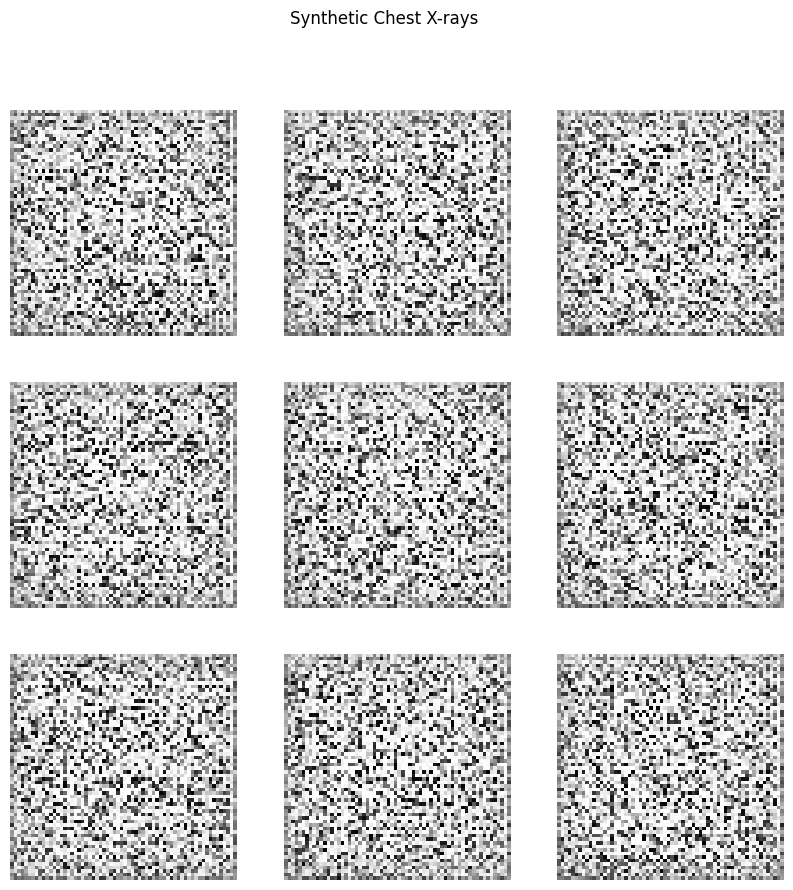

In [92]:
files = os.listdir("synthetic_xrays")

plt.figure(figsize=(10,10))

for i in range(9):

    img = Image.open("synthetic_xrays/"+files[i])

    plt.subplot(3,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.axis("off")

plt.suptitle("Synthetic Chest X-rays")

# **Exercise 3: Art Style Transfer (Creativity & Filters)**

In [93]:
!pip install kagglehub torch torchvision matplotlib tqdm

In [94]:
import kagglehub
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.utils import make_grid
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [95]:
path = kagglehub.dataset_download("balraj98/monet2photo")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'monet2photo' dataset.
Dataset Path: /kaggle/input/monet2photo


In [96]:
train_monet_dir = os.path.join(path, "trainA")
train_photo_dir = os.path.join(path, "trainB")

print(len(os.listdir(train_monet_dir)), "Monet images")
print(len(os.listdir(train_photo_dir)), "Photo images")

1072 Monet images
6287 Photo images


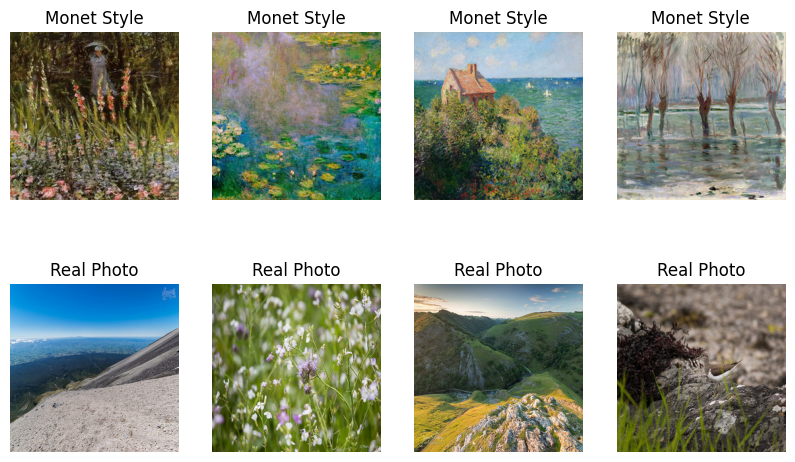

In [97]:
plt.figure(figsize=(10,6))

for i in range(4):

    monet = Image.open(os.path.join(train_monet_dir,
              random.choice(os.listdir(train_monet_dir))))

    photo = Image.open(os.path.join(train_photo_dir,
              random.choice(os.listdir(train_photo_dir))))

    plt.subplot(2,4,i+1)
    plt.imshow(monet)
    plt.title("Monet Style")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(photo)
    plt.title("Real Photo")
    plt.axis("off")

plt.show()

In [98]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [99]:
class MonetPhotoDataset(Dataset):

    def __init__(self, monet_dir, photo_dir, transform):

        self.monet_dir = monet_dir
        self.photo_dir = photo_dir

        self.monet_images = os.listdir(monet_dir)
        self.photo_images = os.listdir(photo_dir)

        self.transform = transform

    def __len__(self):
        return max(len(self.monet_images), len(self.photo_images))

    def __getitem__(self, idx):

        monet = Image.open(os.path.join(
            self.monet_dir,
            self.monet_images[idx % len(self.monet_images)]
        )).convert("RGB")

        photo = Image.open(os.path.join(
            self.photo_dir,
            self.photo_images[random.randint(0,len(self.photo_images)-1)]
        )).convert("RGB")

        monet = self.transform(monet)
        photo = self.transform(photo)

        return monet, photo

In [100]:
dataset = MonetPhotoDataset(
    train_monet_dir,
    train_photo_dir,
    transform
)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

Text(0.5, 1.0, 'Real Photos')

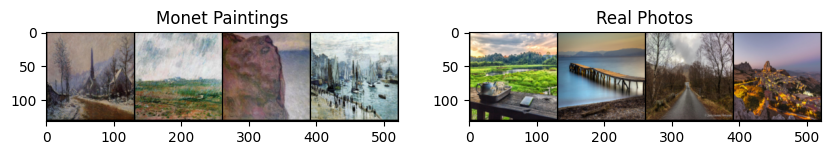

In [101]:
monet, photo = next(iter(loader))

grid_monet = make_grid(monet[:4], normalize=True)
grid_photo = make_grid(photo[:4], normalize=True)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(grid_monet.permute(1,2,0))
plt.title("Monet Paintings")

plt.subplot(1,2,2)
plt.imshow(grid_photo.permute(1,2,0))
plt.title("Real Photos")

In [102]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,7,1,3),
            nn.ReLU(),

            nn.Conv2d(64,128,3,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,256,3,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256,128,3,2,1,output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,3,2,1,output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,3,7,1,3),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [103]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [104]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G_photo_to_monet = Generator().to(device)
G_monet_to_photo = Generator().to(device)

D_monet = Discriminator().to(device)
D_photo = Discriminator().to(device)

In [105]:
adv_loss = nn.BCELoss()
cycle_loss = nn.L1Loss()

opt_G = optim.Adam(
    list(G_photo_to_monet.parameters()) +
    list(G_monet_to_photo.parameters()),
    lr=0.0002
)

opt_D = optim.Adam(
    list(D_monet.parameters()) +
    list(D_photo.parameters()),
    lr=0.0002
)

In [106]:
epochs = 5

for epoch in range(epochs):

    loop = tqdm(loader)

    for monet, photo in loop:

        monet = monet.to(device)
        photo = photo.to(device)

        fake_monet = G_photo_to_monet(photo)
        fake_photo = G_monet_to_photo(monet)

        # Cycle consistency
        cycle_photo = G_monet_to_photo(fake_monet)
        cycle_monet = G_photo_to_monet(fake_photo)

        loss_cycle = cycle_loss(cycle_photo, photo) + cycle_loss(cycle_monet, monet)

        opt_G.zero_grad()
        loss_cycle.backward()
        opt_G.step()

        loop.set_description(f"Epoch {epoch}")

Epoch 4: 100%|██████████| 1572/1572 [02:50<00:00,  9.21it/s]


In [109]:
photo_batch = next(iter(loader))[1].to(device)

with torch.no_grad():
    fake_monet = G_photo_to_monet(photo_batch)

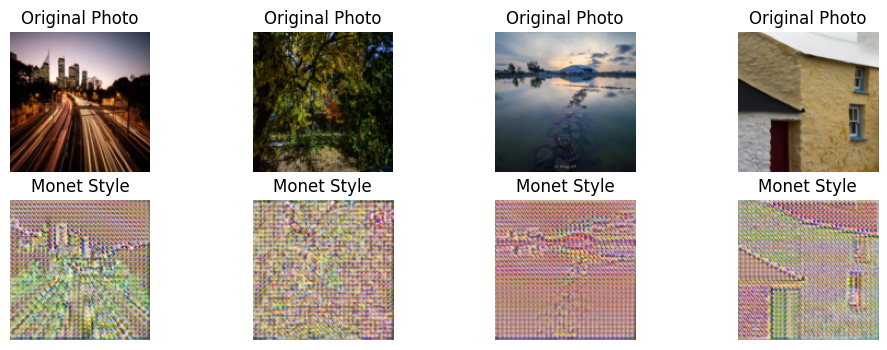

In [110]:
plt.figure(figsize=(12,4))

for i in range(4):

    plt.subplot(2,4,i+1)
    plt.imshow(photo_batch[i].cpu().permute(1,2,0)*0.5+0.5)
    plt.title("Original Photo")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(fake_monet[i].cpu().permute(1,2,0)*0.5+0.5)
    plt.title("Monet Style")
    plt.axis("off")

plt.show()